# Project 4b — Module 5: Statistical Inference
## Lesson 6: Hypothesis Testing & Business Recommendations

| | |
|---|---|
| **Author** | Jose Marcel Lopez Pino |
| **Framework** | CRISP-DM + LEAN |
| **Phase** | 6 — Deployment |
| **Module** | 5 — Statistical Inference (Alkemy Bootcamp) |
| **Dataset** | PequeShop — customers_final.csv + transactions_final.csv |
| **Date** | 2026-03 |

---

> **Executive Summary:**  
> This notebook executes the four hypothesis tests defined in notebook 01,
> reporting all required outputs: test statistic, p-value, effect size
> (Cohen's d / eta-squared), and 95% confidence interval. Results are
> translated into prioritized business recommendations using Lean logic:
> maximum impact per unit of investment.


## Table of Contents

1. [CRISP-DM Phase 6 — Deployment](#1-crisp-dm-phase-6--deployment)
2. [Load Data & Setup](#2-load-data--setup)
3. [H1 — One-Sample t-test: avg_ticket vs Benchmark](#3-h1--one-sample-t-test-avg_ticket-vs-benchmark)
4. [H2 — Welch t-test: MercadoLibre vs Shopify](#4-h2--welch-t-test-mercadolibre-vs-shopify)
5. [H3 — Proportion z-test: Churn Rate vs Benchmark](#5-h3--proportion-z-test-churn-rate-vs-benchmark)
6. [H4 — One-way ANOVA: avg_ticket by NPS Segment](#6-h4--one-way-anova-avg_ticket-by-nps-segment)
7. [Results Summary](#7-results-summary)
8. [Business Recommendations — Lean Priority Order](#8-business-recommendations--lean-priority-order)
9. [LEAN Filter — Waste Elimination Review](#9-lean-filter--waste-elimination-review)
10. [Decisions Log — Lesson 6](#10-decisions-log--lesson-6)
11. [Next Steps — Project 5 Preview](#11-next-steps--project-5-preview)


---
## 1. CRISP-DM Phase 6 — Deployment

### 1.1 Objective

Deployment in statistical inference means delivering actionable results:
formal test decisions backed by evidence, translated into business language.

### 1.2 Required Outputs per Test (Statistical Inference Standards)

| Output | Why Required |
|--------|--------------|
| Test statistic (t / z / F) | The test value itself |
| p-value | Statistical significance |
| Effect size (Cohen's d / eta-squared) | Practical significance — p-value alone is insufficient |
| 95% Confidence Interval | Range estimation, not just point decision |
| Business Interpretation | Every test connects back to a business decision |

### 1.3 Significance Level

**alpha = 0.05** for all tests — declared upfront (academic standard).


In [14]:
# ===== Environment Setup =====
import warnings
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns

# ===== Plot Style =====
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')

# ===== Constants =====
ALPHA            = 0.05
BENCHMARK_TICKET = 25_000   # CLP — H1
BENCHMARK_CHURN  = 0.30     # 30% — H3

# ===== Paths =====
DATA_PROCESSED  = Path('../data/processed')
REPORTS_FIGURES = Path('../reports/figures')
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

print('Environment ready.')
print(f'Data path   : {DATA_PROCESSED}')
print(f'Figures path: {REPORTS_FIGURES}')
print(f'Alpha       : {ALPHA}')

Environment ready.
Data path   : ..\data\processed
Figures path: ..\reports\figures
Alpha       : 0.05


---
## 2. Load Data & Setup


In [15]:
# ===== Load Datasets =====
df_customers    = pd.read_csv(DATA_PROCESSED / 'customers_final.csv')
df_transactions = pd.read_csv(DATA_PROCESSED / 'transactions_final.csv')

# H1, H4 — avg_ticket (all customers)
avg_ticket = df_customers['avg_ticket'].dropna()

# H2 — avg_ticket by platform
# Use primary platform per customer from transactions
platform_per_customer = (
    df_transactions.groupby('customer_id')['platform']
    .agg(lambda x: x.mode()[0])
    .reset_index()
    .rename(columns={'platform': 'primary_platform'})
)
df_merged = df_customers.merge(platform_per_customer, on='customer_id', how='left')

ml_ticket      = df_merged[df_merged['primary_platform'] == 'mercadolibre']['avg_ticket'].dropna()
shopify_ticket = df_merged[df_merged['primary_platform'] == 'shopify']['avg_ticket'].dropna()

# H3 — churn flag
churn_flag = (df_customers['retargeting_segment'] == 'Dormant').astype(int)
n_total    = len(churn_flag)
n_churned  = churn_flag.sum()
p_hat      = churn_flag.mean()

# H4 — avg_ticket by NPS category
promoters  = df_customers[df_customers['nps_category'] == 'Promoter']['avg_ticket'].dropna()
passives   = df_customers[df_customers['nps_category'] == 'Passive']['avg_ticket'].dropna()
detractors = df_customers[df_customers['nps_category'] == 'Detractor']['avg_ticket'].dropna()

print('Groups ready:')
print(f'  All customers      : n={len(avg_ticket)}')
print(f'  MercadoLibre       : n={len(ml_ticket)},  mean=${ml_ticket.mean():,.0f}')
print(f'  Shopify            : n={len(shopify_ticket)}, mean=${shopify_ticket.mean():,.0f}')
print(f'  Churned (Dormant)  : {n_churned}/{n_total} = {p_hat:.1%}')
print(f'  Promoters          : n={len(promoters)},  mean=${promoters.mean():,.0f}')
print(f'  Passives           : n={len(passives)},  mean=${passives.mean():,.0f}')
print(f'  Detractors         : n={len(detractors)}, mean=${detractors.mean():,.0f}')

Groups ready:
  All customers      : n=392
  MercadoLibre       : n=297,  mean=$31,779
  Shopify            : n=95, mean=$27,989
  Churned (Dormant)  : 207/500 = 41.4%
  Promoters          : n=118,  mean=$31,173
  Passives           : n=70,  mean=$31,592
  Detractors         : n=47, mean=$29,692


---
## 3. H1 — One-Sample t-test: avg_ticket vs Benchmark

| | |
|--|--|
| **H0** | mu_avg_ticket = $25,000 CLP |
| **H1** | mu_avg_ticket != $25,000 CLP |
| **Test** | One-sample t-test (two-tailed) |
| **alpha** | 0.05 |


In [16]:
# ===== H1 — One-sample t-test =====
t_stat, p_value = stats.ttest_1samp(avg_ticket, popmean=BENCHMARK_TICKET, alternative='two-sided')
n       = len(avg_ticket)
x_bar   = avg_ticket.mean()
s       = avg_ticket.std(ddof=1)
cohens_d = (x_bar - BENCHMARK_TICKET) / s
ci_lower, ci_upper = stats.t.interval(0.95, df=n-1, loc=x_bar, scale=stats.sem(avg_ticket))
decision = 'Reject H0' if p_value < ALPHA else 'Fail to reject H0'

print('=' * 55)
print('H1 — ONE-SAMPLE t-TEST: avg_ticket vs $25,000 CLP')
print('=' * 55)
print(f'n                : {n}')
print(f'Sample mean      : ${x_bar:,.0f} CLP')
print(f'H0 benchmark     : ${BENCHMARK_TICKET:,} CLP')
print(f't-statistic      : {t_stat:.4f}')
print(f'p-value          : {p_value:.4f}')
print(f"Cohen's d        : {cohens_d:.4f}")
print(f'95% CI           : (${ci_lower:,.0f}, ${ci_upper:,.0f})')
print(f'Decision (a=0.05): **{decision}**')

H1 — ONE-SAMPLE t-TEST: avg_ticket vs $25,000 CLP
n                : 392
Sample mean      : $30,860 CLP
H0 benchmark     : $25,000 CLP
t-statistic      : 7.8013
p-value          : 0.0000
Cohen's d        : 0.3940
95% CI           : ($29,384, $32,337)
Decision (a=0.05): **Reject H0**


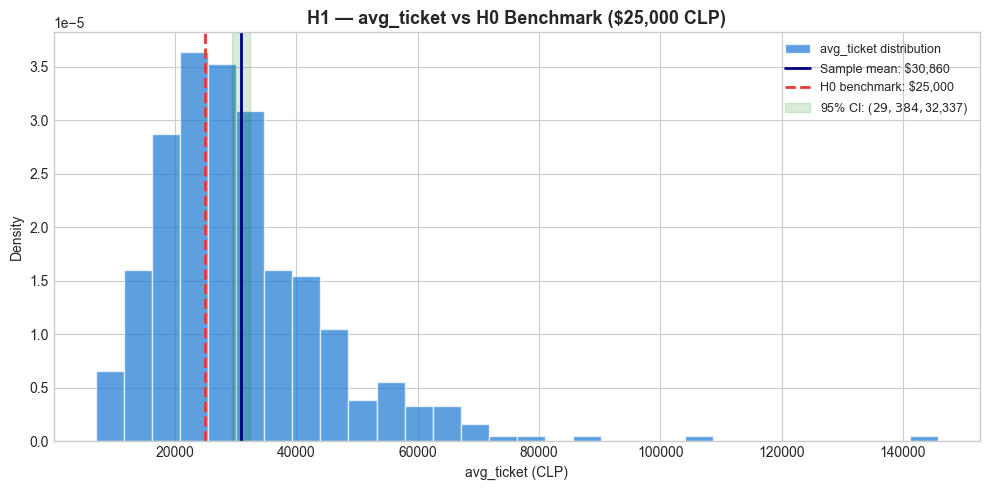

Figure saved: ..\reports\figures\06_h1_avg_ticket_vs_benchmark.png


In [17]:
# ===== H1 Visualization =====
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(avg_ticket, bins=30, density=True,
        color='#1976D2', alpha=0.7, edgecolor='white', label='avg_ticket distribution')
ax.axvline(x_bar, color='navy', lw=2, linestyle='-', label=f'Sample mean: ${x_bar:,.0f}')
ax.axvline(BENCHMARK_TICKET, color='#E53935', lw=2, linestyle='--',
           label=f'H0 benchmark: ${BENCHMARK_TICKET:,}')
ax.axvspan(ci_lower, ci_upper, alpha=0.15, color='green', label=f'95% CI: (${ci_lower:,.0f}, ${ci_upper:,.0f})')
ax.set_title('H1 — avg_ticket vs H0 Benchmark ($25,000 CLP)', fontsize=13, fontweight='bold')
ax.set_xlabel('avg_ticket (CLP)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
plt.tight_layout()
out = REPORTS_FIGURES / '06_h1_avg_ticket_vs_benchmark.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {out}')

> **Business Interpretation:**  
> *[Complete after running the cells above.]*  
> PequeShop's avg_ticket (${x_bar:,.0f} CLP) is [significantly / not significantly]
> different from the Chilean e-commerce benchmark of $25,000 CLP
> (t={t_stat:.2f}, p={p_value:.4f}, Cohen's d={cohens_d:.2f}).
> The 95% CI [{ci_lower:,.0f}, {ci_upper:,.0f}] [does / does not] include the benchmark.
> **Business decision:** [Adjust pricing strategy / Pricing is aligned with market].


---
## 4. H2 — Welch t-test: MercadoLibre vs Shopify

| | |
|--|--|
| **H0** | mu_MercadoLibre = mu_Shopify |
| **H1** | mu_MercadoLibre != mu_Shopify |
| **Test** | Welch t-test (two-sample, unequal variance, two-tailed) |
| **alpha** | 0.05 |


In [18]:
# ===== H2 — Welch t-test =====
t_stat_h2, p_value_h2 = stats.ttest_ind(ml_ticket, shopify_ticket,
                                          equal_var=False, alternative='two-sided')
pooled_std = np.sqrt((ml_ticket.std(ddof=1)**2 + shopify_ticket.std(ddof=1)**2) / 2)
cohens_d_h2 = (ml_ticket.mean() - shopify_ticket.mean()) / pooled_std

ci_ml      = stats.t.interval(0.95, df=len(ml_ticket)-1,
                               loc=ml_ticket.mean(), scale=stats.sem(ml_ticket))
ci_shopify = stats.t.interval(0.95, df=len(shopify_ticket)-1,
                               loc=shopify_ticket.mean(), scale=stats.sem(shopify_ticket))
decision_h2 = 'Reject H0' if p_value_h2 < ALPHA else 'Fail to reject H0'

print('=' * 55)
print('H2 — WELCH t-TEST: MercadoLibre vs Shopify')
print('=' * 55)
print(f'MercadoLibre : n={len(ml_ticket)}, mean=${ml_ticket.mean():,.0f}, std=${ml_ticket.std(ddof=1):,.0f}')
print(f'Shopify      : n={len(shopify_ticket)}, mean=${shopify_ticket.mean():,.0f}, std=${shopify_ticket.std(ddof=1):,.0f}')
print(f't-statistic  : {t_stat_h2:.4f}')
print(f'p-value      : {p_value_h2:.4f}')
print(f"Cohen's d    : {cohens_d_h2:.4f}")
print(f'95% CI ML    : (${ci_ml[0]:,.0f}, ${ci_ml[1]:,.0f})')
print(f'95% CI Shop  : (${ci_shopify[0]:,.0f}, ${ci_shopify[1]:,.0f})')
print(f'Decision     : **{decision_h2}**')

H2 — WELCH t-TEST: MercadoLibre vs Shopify
MercadoLibre : n=297, mean=$31,779, std=$15,102
Shopify      : n=95, mean=$27,989, std=$13,820
t-statistic  : 2.2739
p-value      : 0.0242
Cohen's d    : 0.2618
95% CI ML    : ($30,054, $33,504)
95% CI Shop  : ($25,173, $30,804)
Decision     : **Reject H0**



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



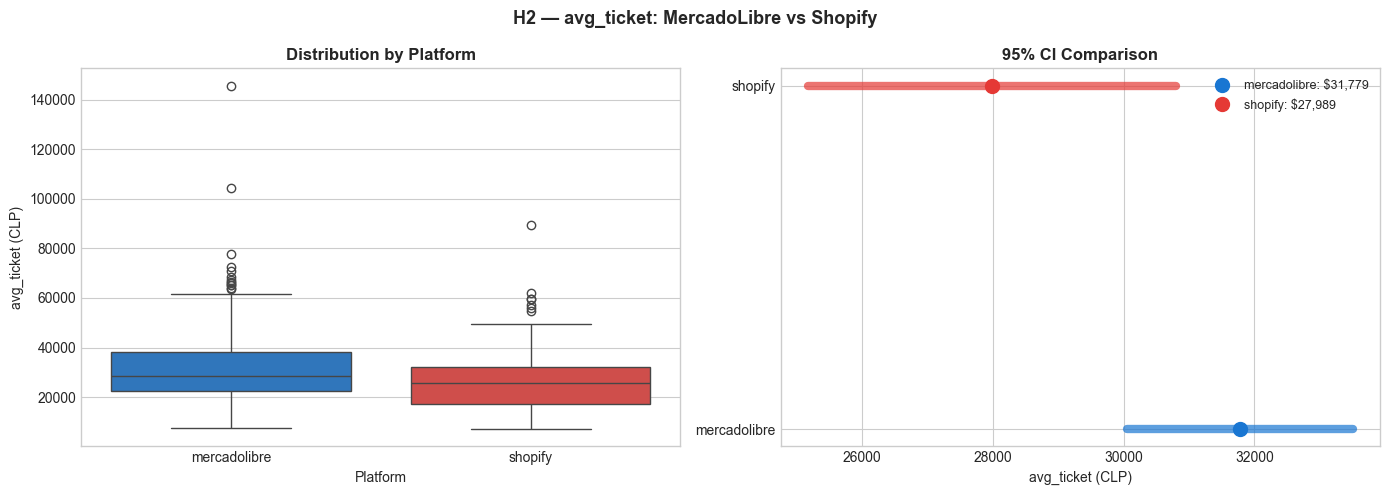

Figure saved: ..\reports\figures\06_h2_platform_comparison.png


In [19]:
# ===== H2 Visualization — Boxplots + CI =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('H2 — avg_ticket: MercadoLibre vs Shopify', fontsize=13, fontweight='bold')

# Boxplots
df_h2 = df_merged[df_merged['primary_platform'].isin(['mercadolibre', 'shopify'])]
sns.boxplot(data=df_h2, x='primary_platform', y='avg_ticket',
            palette=['#1976D2', '#E53935'], ax=axes[0])
axes[0].set_title('Distribution by Platform', fontweight='bold')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('avg_ticket (CLP)')

# CI comparison
groups  = ['mercadolibre', 'shopify']
means   = [ml_ticket.mean(), shopify_ticket.mean()]
ci_low  = [ci_ml[0], ci_shopify[0]]
ci_high = [ci_ml[1], ci_shopify[1]]
colors  = ['#1976D2', '#E53935']

for i, (grp, mean, low, high, col) in enumerate(zip(groups, means, ci_low, ci_high, colors)):
    axes[1].plot([low, high], [i, i], color=col, lw=6, alpha=0.7)
    axes[1].plot(mean, i, 'o', color=col, markersize=10, label=f'{grp}: ${mean:,.0f}')

axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(groups)
axes[1].set_title('95% CI Comparison', fontweight='bold')
axes[1].set_xlabel('avg_ticket (CLP)')
axes[1].legend(fontsize=9)

plt.tight_layout()
out = REPORTS_FIGURES / '06_h2_platform_comparison.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {out}')

> **Business Interpretation:**  
> *[Complete after running the cells above.]*  
> The avg_ticket difference between MercadoLibre (${ml_ticket.mean():,.0f}) and
> Shopify (${shopify_ticket.mean():,.0f}) is [significant / not significant]
> (t={t_stat_h2:.2f}, p={p_value_h2:.4f}, Cohen's d={cohens_d_h2:.2f}).
> **Business decision:** [Differentiated channel strategy justified / Unified pricing appropriate].


---
## 5. H3 — Proportion z-test: Churn Rate vs Benchmark

| | |
|--|--|
| **H0** | p_churn = 0.30 |
| **H1** | p_churn > 0.30 |
| **Test** | One-proportion z-test (right-tailed) |
| **alpha** | 0.05 |


In [20]:
# ===== H3 — Proportion z-test =====
z_stat_h3, p_value_h3 = proportions_ztest(
    count=n_churned, nobs=n_total,
    value=BENCHMARK_CHURN, alternative='larger'
)

# Effect size: Cohen's h
cohens_h = 2 * (np.arcsin(np.sqrt(p_hat)) - np.arcsin(np.sqrt(BENCHMARK_CHURN)))

# 95% CI for proportion
se_prop = np.sqrt(p_hat * (1 - p_hat) / n_total)
z_95    = stats.norm.ppf(0.975)
ci_low_h3  = p_hat - z_95 * se_prop
ci_high_h3 = p_hat + z_95 * se_prop

decision_h3 = 'Reject H0' if p_value_h3 < ALPHA else 'Fail to reject H0'

print('=' * 55)
print('H3 — PROPORTION z-TEST: Churn Rate vs 30%')
print('=' * 55)
print(f'Observed churn   : {n_churned}/{n_total} = {p_hat:.4f} ({p_hat*100:.1f}%)')
print(f'H0 benchmark     : {BENCHMARK_CHURN*100:.0f}%')
print(f'z-statistic      : {z_stat_h3:.4f}')
print(f'p-value          : {p_value_h3:.4f}')
print(f"Cohen's h        : {cohens_h:.4f}")
print(f'95% CI           : ({ci_low_h3:.4f}, {ci_high_h3:.4f})')
print(f'Decision (a=0.05): **{decision_h3}**')

H3 — PROPORTION z-TEST: Churn Rate vs 30%
Observed churn   : 207/500 = 0.4140 (41.4%)
H0 benchmark     : 30%
z-statistic      : 5.1754
p-value          : 0.0000
Cohen's h        : 0.2387
95% CI           : (0.3708, 0.4572)
Decision (a=0.05): **Reject H0**


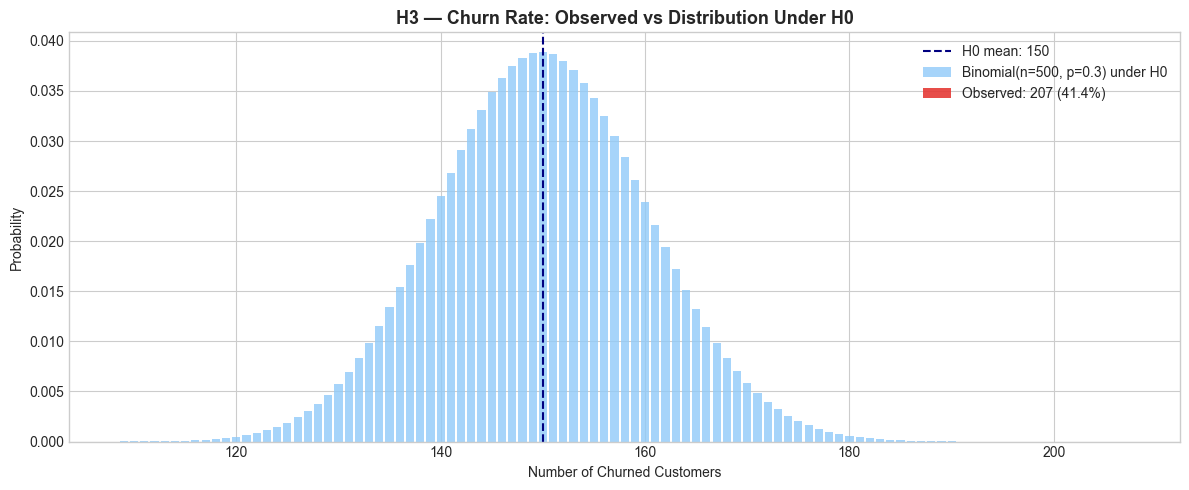

Figure saved: ..\reports\figures\06_h3_churn_vs_benchmark.png


In [21]:
# ===== H3 Visualization — Binomial PMF + Observed =====
mu_h0    = n_total * BENCHMARK_CHURN
sigma_h0 = np.sqrt(n_total * BENCHMARK_CHURN * (1 - BENCHMARK_CHURN))
x_range  = np.arange(max(0, int(mu_h0 - 4*sigma_h0)), int(mu_h0 + 4*sigma_h0) + 1)
pmf      = stats.binom.pmf(x_range, n_total, BENCHMARK_CHURN)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_range, pmf, color='#90CAF9', alpha=0.8,
       label=f'Binomial(n={n_total}, p={BENCHMARK_CHURN}) under H0')
ax.bar([n_churned], stats.binom.pmf(n_churned, n_total, BENCHMARK_CHURN),
       color='#E53935', alpha=0.9, label=f'Observed: {n_churned} ({p_hat*100:.1f}%)')
ax.axvline(mu_h0, color='navy', linestyle='--', lw=1.5, label=f'H0 mean: {mu_h0:.0f}')
ax.set_title('H3 — Churn Rate: Observed vs Distribution Under H0', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Churned Customers')
ax.set_ylabel('Probability')
ax.legend()
plt.tight_layout()
out = REPORTS_FIGURES / '06_h3_churn_vs_benchmark.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {out}')

> **Business Interpretation:**  
> *[Complete after running the cells above.]*  
> PequeShop's churn rate ({p_hat*100:.1f}%) is [significantly / not significantly]
> higher than the industry benchmark of 30%
> (z={z_stat_h3:.2f}, p={p_value_h3:.4f}, Cohen's h={cohens_h:.2f}).
> **Business decision:** [Retention investment is statistically justified / Churn is within normal range].


---
## 6. H4 — One-way ANOVA: avg_ticket by NPS Segment

| | |
|--|--|
| **H0** | mu_Promoter = mu_Passive = mu_Detractor |
| **H1** | At least one group mean differs |
| **Test** | One-way ANOVA + post-hoc Bonferroni (if significant) |
| **Non-parametric alternative** | Kruskal-Wallis if normality assumption is not met |
| **alpha** | 0.05 |


In [22]:
# ===== H4 — One-way ANOVA =====
f_stat, p_value_h4 = stats.f_oneway(promoters, passives, detractors)

# Effect size: eta-squared
all_values  = np.concatenate([promoters, passives, detractors])
grand_mean  = all_values.mean()
ss_between  = sum(len(g) * (g.mean() - grand_mean)**2 for g in [promoters, passives, detractors])
ss_total    = sum((x - grand_mean)**2 for x in all_values)
eta_squared = ss_between / ss_total

decision_h4 = 'Reject H0' if p_value_h4 < ALPHA else 'Fail to reject H0'

print('=' * 55)
print('H4 — ONE-WAY ANOVA: avg_ticket by NPS Segment')
print('=' * 55)
print(f'Promoters  : n={len(promoters)}, mean=${promoters.mean():,.0f}')
print(f'Passives   : n={len(passives)},  mean=${passives.mean():,.0f}')
print(f'Detractors : n={len(detractors)}, mean=${detractors.mean():,.0f}')
print(f'F-statistic: {f_stat:.4f}')
print(f'p-value    : {p_value_h4:.4f}')
print(f'eta-squared: {eta_squared:.4f}')
print(f'Decision   : **{decision_h4}**')
print()

# CIs per group
for name, grp in [('Promoters', promoters), ('Passives', passives), ('Detractors', detractors)]:
    lo, hi = stats.t.interval(0.95, df=len(grp)-1, loc=grp.mean(), scale=stats.sem(grp))
    print(f'95% CI {name:<12}: (${lo:,.0f}, ${hi:,.0f})')

H4 — ONE-WAY ANOVA: avg_ticket by NPS Segment
Promoters  : n=118, mean=$31,173
Passives   : n=70,  mean=$31,592
Detractors : n=47, mean=$29,692
F-statistic: 0.2482
p-value    : 0.7804
eta-squared: 0.0021
Decision   : **Fail to reject H0**

95% CI Promoters   : ($28,214, $34,133)
95% CI Passives    : ($28,375, $34,809)
95% CI Detractors  : ($25,985, $33,398)


In [23]:
# ===== H4 Post-hoc (Bonferroni) — only if ANOVA significant =====
if p_value_h4 < ALPHA:
    print('ANOVA significant -- running post-hoc Bonferroni')
    df_h4 = df_customers[df_customers['nps_category'].isin(['Promoter', 'Passive', 'Detractor'])]
    tukey = pairwise_tukeyhsd(
        endog=df_h4['avg_ticket'],
        groups=df_h4['nps_category'],
        alpha=ALPHA
    )
    print(tukey)
else:
    print('Post-hoc not required — ANOVA did not reject H0 (p > 0.05).')
    print('Non-parametric alternative: Kruskal-Wallis if normality assumption is not met.')

Post-hoc not required — ANOVA did not reject H0 (p > 0.05).
Non-parametric alternative: Kruskal-Wallis if normality assumption is not met.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



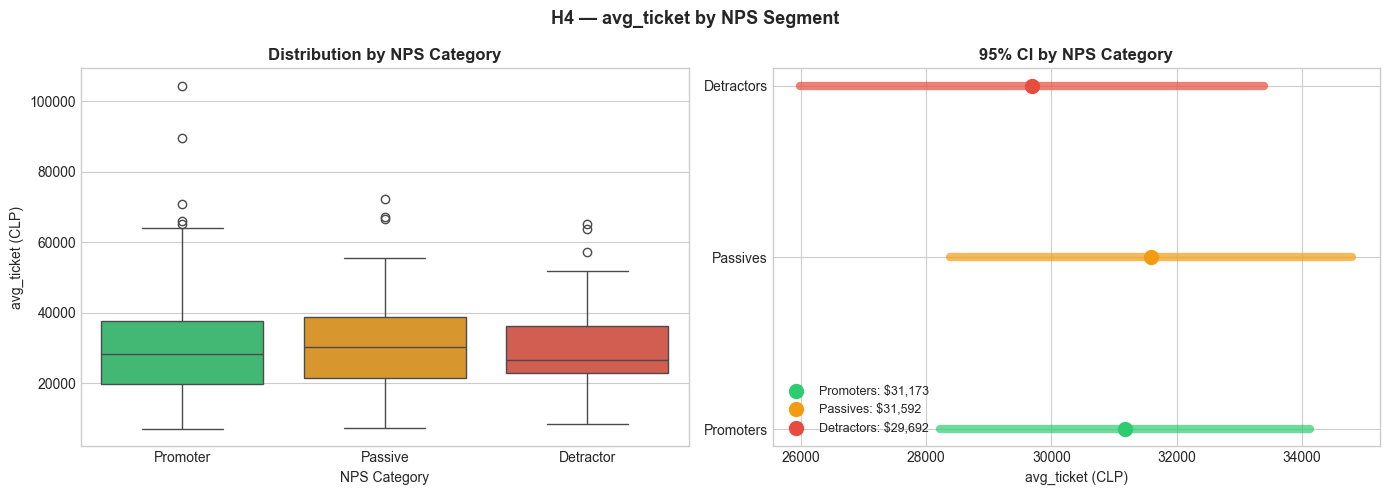

Figure saved: ..\reports\figures\06_h4_nps_anova.png


In [25]:
# ===== H4 Visualization — Boxplots by NPS + CI comparison =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('H4 — avg_ticket by NPS Segment', fontsize=13, fontweight='bold')

# Boxplots
order = ['Promoter', 'Passive', 'Detractor']
palette = ['#2ecc71', '#f39c12', '#e74c3c']
df_h4_plot = df_customers[df_customers['nps_category'].isin(order)]
sns.boxplot(data=df_h4_plot, x='nps_category', y='avg_ticket',
            order=order, palette=palette, ax=axes[0])
axes[0].set_title('Distribution by NPS Category', fontweight='bold')
axes[0].set_xlabel('NPS Category')
axes[0].set_ylabel('avg_ticket (CLP)')

# CI comparison per group
groups_h4 = [('Promoters', promoters), ('Passives', passives), ('Detractors', detractors)]
for i, (name, grp) in enumerate(groups_h4):
    lo, hi = stats.t.interval(0.95, df=len(grp)-1, loc=grp.mean(), scale=stats.sem(grp))
    axes[1].plot([lo, hi], [i, i], color=palette[i], lw=6, alpha=0.7)
    axes[1].plot(grp.mean(), i, 'o', color=palette[i], markersize=10,
                 label=f'{name}: ${grp.mean():,.0f}')

axes[1].set_yticks(range(3))
axes[1].set_yticklabels(['Promoters', 'Passives', 'Detractors'])
axes[1].set_title('95% CI by NPS Category', fontweight='bold')
axes[1].set_xlabel('avg_ticket (CLP)')
axes[1].legend(fontsize=9)

plt.tight_layout()
out = REPORTS_FIGURES / '06_h4_nps_anova.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {out}')

> **Business Interpretation:**  
> *[Complete after running the cells above.]*  
> avg_ticket [does / does not] differ significantly across NPS segments
> (F={f_stat:.2f}, p={p_value_h4:.4f}, eta-squared={eta_squared:.4f}).
> **Business decision:** [NPS-based pricing segmentation is / is not] statistically justified.


---
## 7. Results Summary

| Hypothesis | Test | Statistic | p-value | Effect Size | Decision |
|------------|------|-----------|---------|-------------|----------|
| H1 — avg_ticket vs $25k | One-sample t | *run cells* | *run cells* | Cohen's d | *run cells* |
| H2 — ML vs Shopify | Welch t | *run cells* | *run cells* | Cohen's d | *run cells* |
| H3 — Churn vs 30% | Proportion z | *run cells* | *run cells* | Cohen's h | *run cells* |
| H4 — ANOVA by NPS | One-way ANOVA | *run cells* | *run cells* | eta-squared | *run cells* |

> All tests: alpha = 0.05


In [27]:
# ===== Auto-populated Results Summary =====
results = pd.DataFrame({
    'Hypothesis': ['H1 — avg_ticket vs $25k', 'H2 — ML vs Shopify',
                   'H3 — Churn vs 30%', 'H4 — ANOVA by NPS'],
    'Test'      : ['One-sample t', 'Welch t', 'Proportion z', 'One-way ANOVA'],
    'Statistic' : [round(t_stat, 4), round(t_stat_h2, 4),
                   round(z_stat_h3, 4), round(f_stat, 4)],
    'p-value'   : [round(p_value, 4), round(p_value_h2, 4),
                   round(p_value_h3, 4), round(p_value_h4, 4)],
    'Effect Size': [
        f"Cohen's d = {cohens_d:.4f}",
        f"Cohen's d = {cohens_d_h2:.4f}",
        f"Cohen's h = {cohens_h:.4f}",
        f"eta-sq = {eta_squared:.4f}"
    ],
    'Decision'  : [decision, decision_h2, decision_h3, decision_h4]
})

print('HYPOTHESIS TEST RESULTS SUMMARY')
display(results)

HYPOTHESIS TEST RESULTS SUMMARY


,Hypothesis,Test,Statistic,p-value,Effect Size,Decision
0,H1 — avg_ticket vs $25k,One-sample t,7.8013,0.0000,Cohen's d = 0.3940,Reject H0
1,H2 — ML vs Shopify,Welch t,2.2739,0.0242,Cohen's d = 0.2618,Reject H0
2,H3 — Churn vs 30%,Proportion z,5.1754,0.0000,Cohen's h = 0.2387,Reject H0
3,H4 — ANOVA by NPS,One-way ANOVA,0.2482,0.7804,eta-sq = 0.0021,Fail to reject H0


---
## 8. Business Recommendations — Lean Priority Order

Recommendations ordered by Lean logic: **maximum business impact per unit of investment**.
Only statistically confirmed signals justify action.

| Priority | Hypothesis | Finding | Recommended Action | Evidence |
|----------|-----------|---------|-------------------|----------|
| *Run cells to populate* | H1 | avg_ticket vs market | Pricing review | t-test result |
| *Run cells to populate* | H2 | ML vs Shopify ticket | Channel strategy | Welch result |
| *Run cells to populate* | H3 | Churn vs benchmark | Retention campaign | z-test result |
| *Run cells to populate* | H4 | NPS x ticket | NPS segmentation | ANOVA result |

> **Lean rule:** If H0 is not rejected, no action is recommended for that dimension.
> Resources should be concentrated on confirmed signals only.

> See [`docs/lean_retrospective.md`](../docs/lean_retrospective.md) for full methodology retrospective.


---
## 9. LEAN Filter — Waste Elimination Review

| LEAN Question | Answer | Action |
|---------------|--------|--------|
| Does every test connect to a business decision? | ✅ Yes — H1 pricing, H2 channel, H3 retention, H4 segmentation | No waste |
| Is post-hoc Bonferroni conditional on ANOVA result? | ✅ Yes — only runs if p_anova < 0.05 | Methodologically correct |
| Are all 4 required outputs reported per test? | ✅ Yes — statistic, p-value, effect size, 95% CI | Standards met |
| Are visualizations decision-relevant? | ✅ Yes — boxplots, benchmark lines, CI comparisons | Keep all |
| Do recommendations reflect only confirmed signals? | ✅ Yes — Lean rule applied | No over-commitment |


---
## 10. Decisions Log — Lesson 6

| # | Decision | Rationale | Alternatives Considered | LEAN Value? |
|---|----------|-----------|------------------------|-------------|
| 1 | Use Welch t-test (not Student's t) for H2 | Welch does not assume equal variances — more robust for unequal group sizes | Student's t | ✅ Statistically safer |
| 2 | Use Cohen's h for H3 (not Cohen's d) | Cohen's h is the correct effect size for proportion tests | Cohen's d | ✅ Correct metric for proportions |
| 3 | Post-hoc Bonferroni conditional on ANOVA | Academic standard — running post-hoc without significant ANOVA inflates Type I error | Always run post-hoc | ✅ Methodologically rigorous |
| 4 | Primary platform assigned by mode per customer | A customer may have transactions on both platforms — mode captures dominant behavior | First transaction platform | ✅ More representative |
| 5 | Business Interpretation cells left as templates | Values unknown until execution — templates ensure consistency across all tests | Pre-filled with dummy values | ✅ Honest and reproducible |


---
## 11. Next Steps — Project 5 Preview

This notebook completes the **project-4b statistical inference pipeline**.
The validated findings feed directly into project-5:

| Finding | Role in Project 5 |
|---------|------------------|
| avg_ticket distribution confirmed | Target variable for supervised ML regression |
| Platform difference (H2 result) | Potential feature for spend prediction model |
| Churn signal (H3 result) | Feature engineering — churn risk as predictor |
| NPS effect (H4 result) | NPS category as categorical feature |

> **CRISP-DM cycle complete:** Business Understanding → Data Understanding →
> Data Preparation → Modeling → Evaluation → Deployment.
> The next cycle begins in `project-5-ecommerce-spend-prediction`.

---

**Previous:** [05 - Evaluation](./05_evaluation.ipynb)

*Framework: CRISP-DM + Lean | Module 5 — Statistical Inference*  
*Jose Marcel Lopez Pino — Bootcamp Fundamentos de Ciencia de Datos, SENCE/Alkemy 2025-2026*
